# GloBUS Material Efficiency (ME) Teaching Notebook 
 
Only change the 4 ME codes below: `B` (BAU) or `H` (High-efficiency). 

Corresponding Author: Jerry Song; jerrysong0128@gmail.com

This project serves as an interactive guide to the practical implementation of Global Dynamic Building Sand Model (GloBUS).

```cmd
Software version: Python 3.7

This code transfers the social economic development in 26 global regions into the use of sand for the production of building concrete and glass. For the original code & latest updates, see: https:/github.com/Zh-xy/GloBus
The building material model is based on the BUMA model developed by Sebastiaan Deetman (https:/github.com/SPDeetman/BUMA) and the GloBUME model by Xiaoyang Zhong (DOI: 10.5281/zenodo.5171943)
The dynamic stock model is based on the ODYM model developed by Stefan Pauliuk, Uni Freiburg, Germany. For the original code & latest updates, see: https:/github.com/IndEcol/ODYM

@author: Xiaoyang Zhong; x.zhong@cml.leidenuniv.nl
         Sebastiaan Deetman; deetman@cml.leidenuniv.nl

contributions from: Glenn Aguilar; Sylvia Marinova

```
<div style="text-align: center;">
    <img src="./tools/fig/flow_chart.png" alt="My Image: GCAM_MFA" title="GCAM_MFA" width="800"/>
</div>


In [17]:
import sys
import importlib
import warnings
import contextlib
import io
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.append(str((Path.cwd() / 'script').resolve()))
import GloBUS_ME
importlib.reload(GloBUS_ME)
GloBUS_cement_analysis = GloBUS_ME.GloBUS_cement_analysis

# ===== Student input: 4 ME codes (B or H) =====
ME1 = 'B'  # More intensive use of space
ME2 = 'B'  # Lifetime extension
ME3 = 'B'  # Material intensity efficiency
ME4 = 'B'  # End-of-life recycle/reuse

# ===== Student input: ME parameter values =====
intensive_rate = 0.93            # ME1 high value
lifetime_extention_rate = 70/30  # ME2 high value
mi_factor_he = 0.90              # ME3 high value
eol_recycle_reuse_rate = 0.15    # ME4 high value
# ============================================

scenario_code = f'{ME1}{ME2}{ME3}{ME4}'
_buf_out, _buf_err = io.StringIO(), io.StringIO()
with contextlib.redirect_stdout(_buf_out), contextlib.redirect_stderr(_buf_err):
    result = GloBUS_cement_analysis(
        scenario_code,
        verbose=False,
        intensive_rate=intensive_rate,
        lifetime_extention_rate=lifetime_extention_rate,
        mi_factor_he=mi_factor_he,
        eol_recycle_reuse_rate=eol_recycle_reuse_rate,
    )

cement_demand = result['cement_inflow_total']
print('Scenario:', result['scenario_code'])
print('Output CSV:', result.get('cement_inflow_path', result.get('cement_output_path')))


Scenario: BBBB
Output CSV: /Users/jerrysong/Study_PKU/MFA_Workspace/ODYM_Application/summer-school/MFA-Temoa/data/1-mfa/cement_demand_inflow_BBBB.csv


In [18]:
# Load 6 pre-run scenarios and prepare comparison data
import pandas as pd
from pathlib import Path
from tools.tools import SCENARIO_NAMES

base = Path.cwd().parent / 'data' / '1_mfa' / 'pre-run-demand'

total = pd.DataFrame()
for code, name in SCENARIO_NAMES.items():
    df = pd.read_csv(base / f'cement_demand_inflow_{code}.csv', index_col=0)
    df.index = df.index.astype(int)
    total[name] = df.sum(axis=1)

total = total.loc[1970:2060]
value_2060 = total.loc[2060].sort_values(ascending=False)
bau_2060 = value_2060['BAU']
summary = pd.DataFrame({
    'value_2060': value_2060,
    'pct_change_vs_BAU_2060': (value_2060 / bau_2060 - 1) * 100,
}).sort_values('pct_change_vs_BAU_2060', ascending=False)


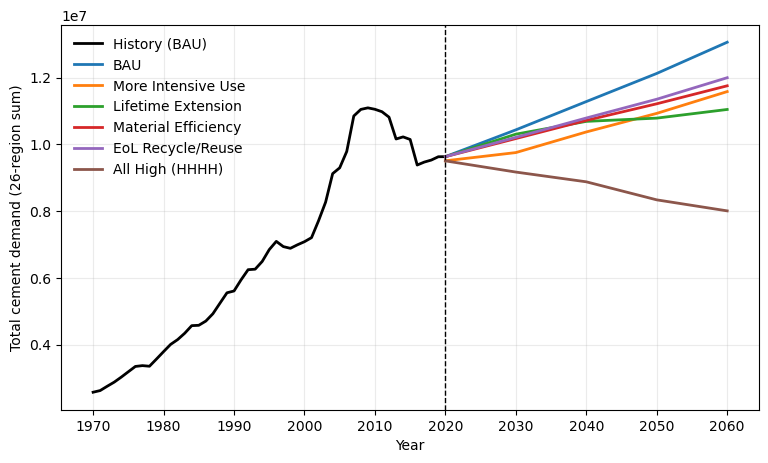

In [19]:
# Plot: 1970-2020 (every year) + 2020-2060 (every 10 years)
import matplotlib.pyplot as plt

hist_years = list(range(1970, 2021))
fut_years = list(range(2020, 2061, 10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_years, total.loc[hist_years, 'BAU'].values, color='black', linewidth=2, label='History (BAU)')
for scen in total.columns:
    ax.plot(fut_years, total.loc[fut_years, scen].values, linewidth=2, label=scen)

ax.axvline(2020, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('Total cement demand (26-region sum)')
ax.set_xticks([1970, 1980, 1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060])
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()


In [20]:
# Table: cumulative comparison
display(summary.round(2))

,value_2060,pct_change_vs_BAU_2060
BAU,13058328.80,0.00
EoL Recycle/Reuse,11994799.64,-8.14
Material Efficiency,11752495.92,-10.00
More Intensive Use,11579242.84,-11.33
Lifetime Extension,11043366.72,-15.43
All High (HHHH),8004706.78,-38.70
